<a href="https://colab.research.google.com/github/Vilasith-c/Case-Study-ML-Cyder-Crime/blob/main/MLsvm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
train_df = pd.read_csv("NSL_KDD_Train.csv")
test_df  = pd.read_csv("NSL_KDD_Test.csv")


In [ ]:
# Raw data preview
print("Before Preprocessing (Raw Data):")
train_df.head()


Before Preprocessing (Raw Data):


,0,tcp,ftp_data,SF,491,0.1,0.2,0.3,0.4,0.5,...,25,0.17,0.03,0.17.1,0.25,0.26,0.27,0.05,0.28,normal
0,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal
1,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune
2,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal
3,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal
4,0,tcp,private,REJ,0,0,0,0,0,0,...,19,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune


In [ ]:
columns = [
 'duration','protocol_type','service','flag','src_bytes','dst_bytes',
 'land','wrong_fragment','urgent','hot','num_failed_logins',
 'logged_in','num_compromised','root_shell','su_attempted','num_root',
 'num_file_creations','num_shells','num_access_files','num_outbound_cmds',
 'is_host_login','is_guest_login','count','srv_count','serror_rate',
 'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate',
 'diff_srv_rate','srv_diff_host_rate','dst_host_count',
 'dst_host_srv_count','dst_host_same_srv_rate',
 'dst_host_diff_srv_rate','dst_host_same_src_port_rate',
 'dst_host_srv_diff_host_rate','dst_host_serror_rate',
 'dst_host_srv_serror_rate','dst_host_rerror_rate',
 'dst_host_srv_rerror_rate','attack_type'
]

train_df.columns = columns
test_df.columns  = columns


In [ ]:
categorical_cols = ['protocol_type', 'service', 'flag']

le = LabelEncoder()
for col in categorical_cols:
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])


In [ ]:
attack_mapping = {
    'normal': 'Normal',

    'back':'DoS','land':'DoS','neptune':'DoS','pod':'DoS','smurf':'DoS','teardrop':'DoS',

    'ipsweep':'Probe','nmap':'Probe','portsweep':'Probe','satan':'Probe',

    'ftp_write':'R2L','guess_passwd':'R2L','imap':'R2L','multihop':'R2L',
    'phf':'R2L','spy':'R2L','warezclient':'R2L','warezmaster':'R2L',

    'buffer_overflow':'U2R','loadmodule':'U2R','perl':'U2R','rootkit':'U2R'
}

train_df['attack_category'] = train_df['attack_type'].map(attack_mapping)
test_df['attack_category']  = test_df['attack_type'].map(attack_mapping)


In [ ]:
train_df = train_df.dropna(subset=['attack_category']).reset_index(drop=True)
test_df  = test_df.dropna(subset=['attack_category']).reset_index(drop=True)


In [ ]:
X_train = train_df.drop(['attack_type','attack_category'], axis=1)
y_train = train_df['attack_category']

X_test  = test_df.drop(['attack_type','attack_category'], axis=1)
y_test  = test_df['attack_category']


In [ ]:
constant_features = X_train.columns[X_train.nunique() == 1]

X_train = X_train.drop(columns=constant_features)
X_test  = X_test.drop(columns=constant_features)


In [ ]:
label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc  = label_encoder.transform(y_test)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [ ]:
print("After Encoding & Cleaning:")
X_train.head()


After Encoding & Cleaning:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,2,44,9,146,0,0,0,0,0,...,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00
1,0,1,49,5,0,0,0,0,0,0,...,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00
2,0,1,24,9,232,8153,0,0,0,0,...,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01
3,0,1,24,9,199,420,0,0,0,0,...,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00
4,0,1,49,1,0,0,0,0,0,0,...,255,19,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00


In [ ]:
selector = SelectKBest(score_func=f_classif, k=15)

X_train_sel = selector.fit_transform(X_train_scaled, y_train_enc)
X_test_sel  = selector.transform(X_test_scaled)

selected_features = X_train.columns[selector.get_support()]
print("Selected Features:")
print(selected_features.tolist())


Selected Features:
['flag', 'logged_in', 'count', 'serror_rate', 'srv_serror_rate', 'same_srv_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_srv_rerror_rate']


In [ ]:
svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    decision_function_shape='ovr'
)

svm_model.fit(X_train_sel, y_train_enc)


SVC(C=10)

In [ ]:
y_pred = svm_model.predict(X_test_sel)

print("Accuracy:", accuracy_score(y_test_enc, y_pred))
print(classification_report(
    y_test_enc,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))


Accuracy: 0.8273825360506571
              precision    recall  f1-score   support

         DoS       0.95      0.93      0.94      5740
      Normal       0.79      0.95      0.86      9711
       Probe       0.64      0.91      0.75      1106
         R2L       0.33      0.00      0.00      2199
         U2R       0.00      0.00      0.00        37

    accuracy                           0.83     18793
   macro avg       0.54      0.56      0.51     18793
weighted avg       0.78      0.83      0.78     18793



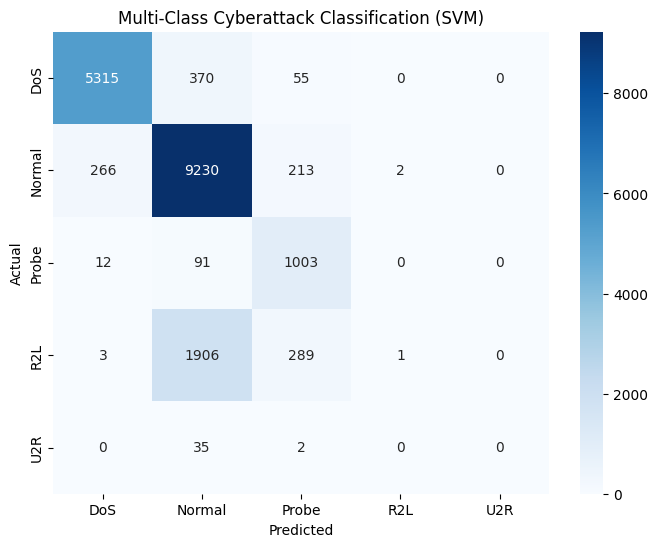

In [ ]:
cm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Multi-Class Cyberattack Classification (SVM)")
plt.show()


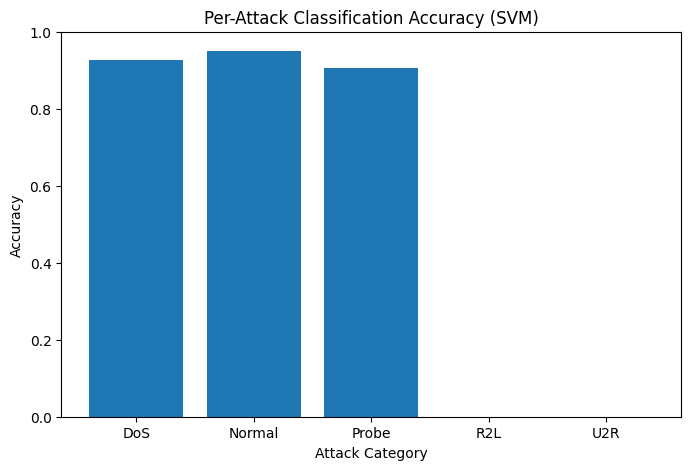

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test_enc, y_pred)

# Per-class accuracy = TP / total samples of that class
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

attack_labels = label_encoder.classes_

# Plot
plt.figure(figsize=(8,5))
plt.bar(attack_labels, per_class_accuracy)
plt.xlabel("Attack Category")
plt.ylabel("Accuracy")
plt.title("Per-Attack Classification Accuracy (SVM)")
plt.ylim(0, 1)
plt.show()


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize labels
y_test_bin = label_binarize(y_test_enc, classes=np.arange(len(attack_labels)))

# Decision scores
y_score = svm_model.decision_function(X_test_sel)


In [ ]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(attack_labels)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


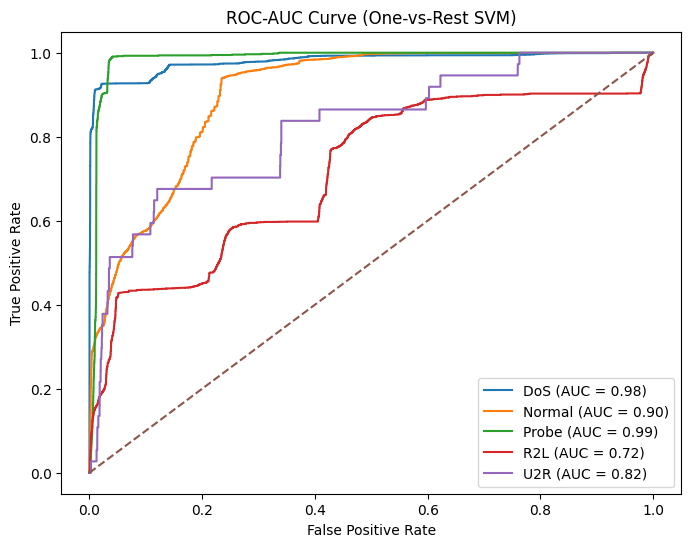

In [ ]:
plt.figure(figsize=(8,6))

for i, label in enumerate(attack_labels):
    plt.plot(fpr[i], tpr[i], label=f"{label} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve (One-vs-Rest SVM)")
plt.legend()
plt.show()


In [ ]:
svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    decision_function_shape='ovr',
    class_weight='balanced'
)


In [ ]:
svm_model.fit(X_train_sel, y_train_enc)

y_pred_bal = svm_model.predict(X_test_sel)

print("Accuracy (Balanced SVM):",
      accuracy_score(y_test_enc, y_pred_bal))

print("\nClassification Report (Balanced SVM):\n")
print(classification_report(
    y_test_enc,
    y_pred_bal,
    target_names=label_encoder.classes_,
    zero_division=0
))


Accuracy (Balanced SVM): 0.8201457989677008

Classification Report (Balanced SVM):

              precision    recall  f1-score   support

         DoS       0.92      0.93      0.92      5740
      Normal       0.81      0.91      0.86      9711
       Probe       0.63      0.80      0.70      1106
         R2L       0.74      0.16      0.26      2199
         U2R       0.02      0.08      0.03        37

    accuracy                           0.82     18793
   macro avg       0.62      0.58      0.55     18793
weighted avg       0.82      0.82      0.80     18793



In [ ]:
from sklearn.metrics import recall_score

print("Recall before balancing:")
print(recall_score(y_test_enc, y_pred, average=None))

print("\nRecall after balancing:")
print(recall_score(y_test_enc, y_pred_bal, average=None))


Recall before balancing:
[9.25958188e-01 9.50468541e-01 9.06871609e-01 4.54752160e-04
 0.00000000e+00]

Recall after balancing:
[0.92682927 0.91205849 0.80108499 0.157799   0.08108108]


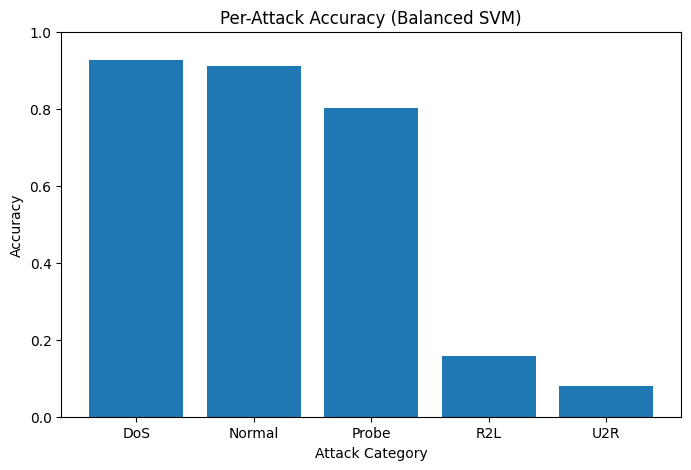

In [ ]:
cm_bal = confusion_matrix(y_test_enc, y_pred_bal)

per_class_accuracy_bal = cm_bal.diagonal() / cm_bal.sum(axis=1)

plt.figure(figsize=(8,5))
plt.bar(label_encoder.classes_, per_class_accuracy_bal)
plt.xlabel("Attack Category")
plt.ylabel("Accuracy")
plt.title("Per-Attack Accuracy (Balanced SVM)")
plt.ylim(0, 1)
plt.show()


In [ ]:
y_score = svm_model.decision_function(X_test_sel)


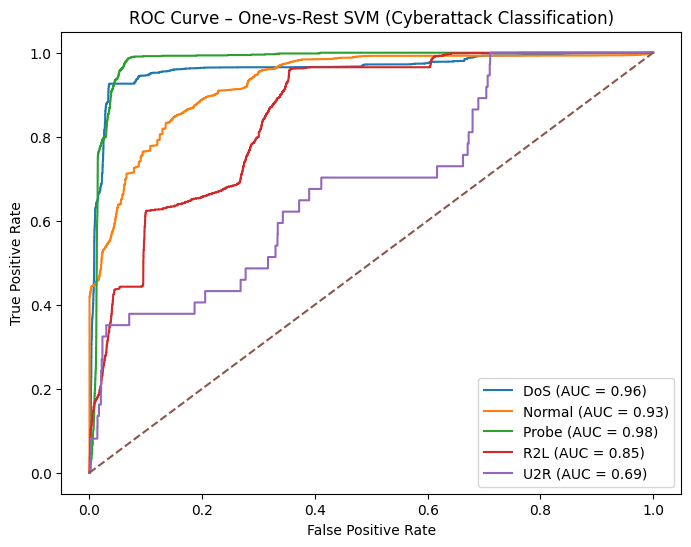

In [ ]:
# Number of classes
n_classes = len(label_encoder.classes_)

# Binarize true labels
y_test_bin = label_binarize(
    y_test_enc,
    classes=np.arange(n_classes)
)
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
plt.figure(figsize=(8,6))

for i, label in enumerate(label_encoder.classes_):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{label} (AUC = {roc_auc[i]:.2f})"
    )

# Random guess line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – One-vs-Rest SVM (Cyberattack Classification)")
plt.legend()
plt.show()





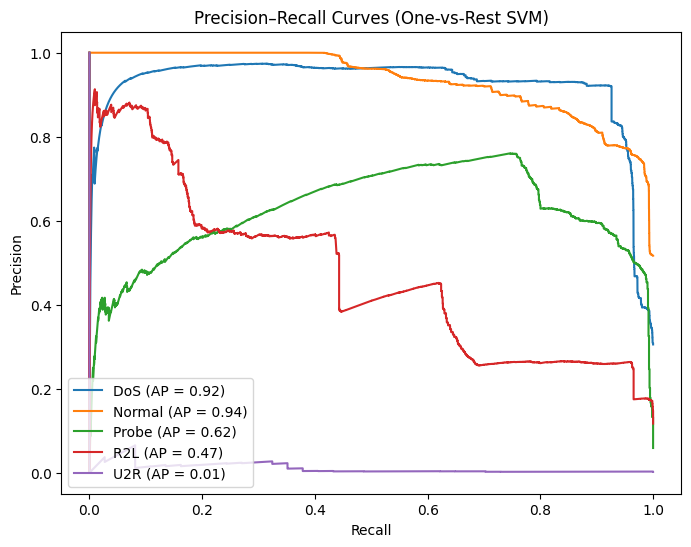

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
n_classes = len(label_encoder.classes_)

y_test_bin = label_binarize(
    y_test_enc,
    classes=np.arange(n_classes)
)
precision = {}
recall = {}
avg_precision = {}

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )
    avg_precision[i] = average_precision_score(
        y_test_bin[:, i],
        y_score[:, i]
    )
plt.figure(figsize=(8,6))

for i, label in enumerate(label_encoder.classes_):
    plt.plot(
        recall[i],
        precision[i],
        label=f"{label} (AP = {avg_precision[i]:.2f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves (One-vs-Rest SVM)")
plt.legend()
plt.show()


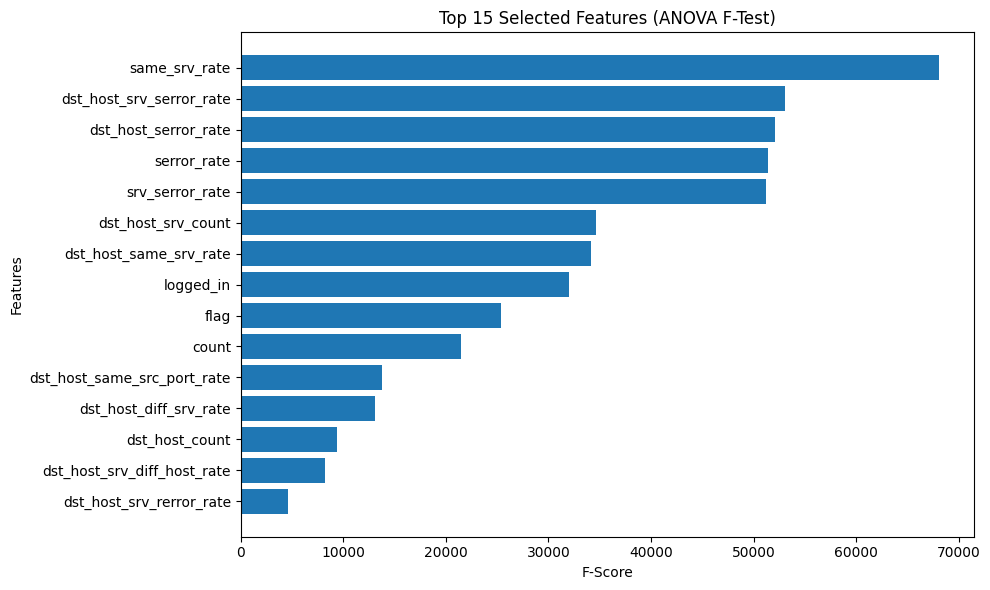

In [ ]:
#Case 1: ANOVA F-test Feature Scores

import numpy as np
import matplotlib.pyplot as plt

scores = selector.scores_
feature_names = X_train.columns   # ✅ correct variable

K = 15
top_idx = np.argsort(scores)[-K:]
top_scores = scores[top_idx]
top_features = feature_names[top_idx]

plt.figure(figsize=(10, 6))
plt.barh(top_features, top_scores)
plt.xlabel("F-Score")
plt.ylabel("Features")
plt.title("Top 15 Selected Features (ANOVA F-Test)")
plt.tight_layout()
plt.show()
